Этот ноутбук показывает процесс, как мы придумали отображать облака слов для описаний книг

In [277]:
!pip install pymorphy3

In [278]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from pymorphy3 import MorphAnalyzer
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import nltk
import numpy as np
import string
from nltk import word_tokenize, pos_tag

https://github.com/hse-ds/iad-intro-ds/blob/master/2025/seminars/11_texts/sem11_texts.ipynb

Для начала скачаем необходимые части nltk - модели, словари и.т.д. Везде будем использовать параметр quiet=True, чтобы не палить имя пользователя компьютера)

Слова, которые создают в основном шум

In [279]:
nltk.download("stopwords", quiet=True)


True

Модель которая может разбивать слова на предложения. В разных версиях nltk используются разные версии модели, но мы скачаем обе (более современная punkt_tab)

In [280]:
nltk.download('punkt', quiet=True)

True

In [281]:
nltk.download('punkt_tab', quiet=True)

True

Модель которая может определять часть речи слова. В разных версиях nltk используются разные версии модели, но мы скачаем обе (более современная averaged_perceptron_tagger_eng). Также скачаем пакет universal_tagset, чтобы определять более "общие" части речи, так как обычно nltk возвращает подробную информацию о части речи. Например, VBD - глагол в прошедшем времени, а благодаря unversal_targset это будет просто VERB

In [282]:
nltk.download('averaged_perceptron_tagger', quiet=True)

True

In [283]:
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

True

In [284]:
nltk.download('universal_tagset', quiet=True)

True

wordnet это лексическая база английского языка, нужна для лемматизации (например, чтобы run определялся как начальная форма running).

In [285]:
nltk.download('wordnet', quiet=True)

True

In [286]:
from string import punctuation

noise = stopwords.words("russian") + list(punctuation) + stopwords.words("english")

In [287]:
pymorphy3_analyzer = MorphAnalyzer()

https://pymorphy2.readthedocs.io/en/stable/user/guide.html#id3

Судя по документации, часть речи можно доставать следующим образом:

In [288]:
pymorphy3_analyzer.parse('яблоко')[0].tag.POS

'NOUN'

In [289]:
pymorphy3_analyzer.parse('красивый')[0].tag.POS

'ADJF'

In [290]:
pymorphy3_analyzer.parse('бегать')[0].tag.POS

'INFN'

Для облака слов мы оставим только глалолы, существительные и прилагательные

Для английского текста удобнее всего использовать библиотеку nltk. pos_tag позволяет выводить информацию о частях речи, не забудем использовать также tagset='unversal', чтобы выводить более "общие" части речи (см. начало ноутбука, где скачивался tagset_universal)

In [ ]:
tokens = word_tokenize('This is a beatiful text. Please understand how to determine a part of the speech')
pos_tag(tokens, tagset='universal')


[('This', 'DET'),
 ('is', 'VERB'),
 ('a', 'DET'),
 ('beatiful', 'ADJ'),
 ('text', 'NOUN'),
 ('.', '.'),
 ('Please', 'NOUN'),
 ('understand', 'VERB'),
 ('how', 'ADV'),
 ('to', 'PRT'),
 ('determine', 'VERB'),
 ('a', 'DET'),
 ('part', 'NOUN'),
 ('of', 'ADP'),
 ('the', 'DET'),
 ('speech', 'NOUN')]

Построим функцию для лемматизации слов одного описания книги. Причем в двух датасетах у нас описания на разных языках, тогда мы будем использовать разные библиотеки - pymorhpy для русского и nltk для английского

In [292]:
def lemmatizer(text, language='en'):
    result = []
    if language == 'ru':
        for word in text.split():
            morphology = pymorphy3_analyzer.parse(word.lower().strip(string.punctuation))[0]
            if morphology.tag.POS not in ['NOUN', 'ADJF', 'INFN']:
                continue
            normal_form = morphology.normal_form
            normal_form = normal_form.replace('ё', 'е')            

            if normal_form not in noise:
                result.append(normal_form)
    elif language == 'en':
        tokens = pos_tag(word_tokenize(text), tagset='universal')
        for token, pos in tokens:
            if pos not in ['VERB', 'NOUN', 'ADJ']:
                continue
            lemmatizer_nltk = WordNetLemmatizer()
            if pos == 'VERB':
                pos_tag_for_norm = 'v'
            elif pos == 'NOUN':
                pos_tag_for_norm = 'n'
            else:
                pos_tag_for_norm = 'a'
            normal_form = lemmatizer_nltk.lemmatize(token, pos_tag_for_norm).lower().strip()
            if normal_form not in noise and "'" not in normal_form:
                result.append(normal_form)
    else:
        return None

    return ' '.join(result)


In [306]:
lemmatizer('это', language='ru')

''

In [304]:
lemmatizer('Привет, Корней. Я твой единственный подписчик. Сейчас я зайду со всех аккаунтов и напишу об этом', language='ru')

'привет корень твой единственный подписчик аккаунт'

In [295]:
lemmatizer("Hi, Kornei. I'm your only follower. I'll log in from all my accounts and write about this", language='en')

'hi kornei follower log account write'

пример построения облака слов описан тут: https://www.geeksforgeeks.org/python/generating-word-cloud-python/

Напишем функцию, которая получает на вход pd.Series с описаниями книг а на выход получает облако слов суммарно из всех описаний выборки 

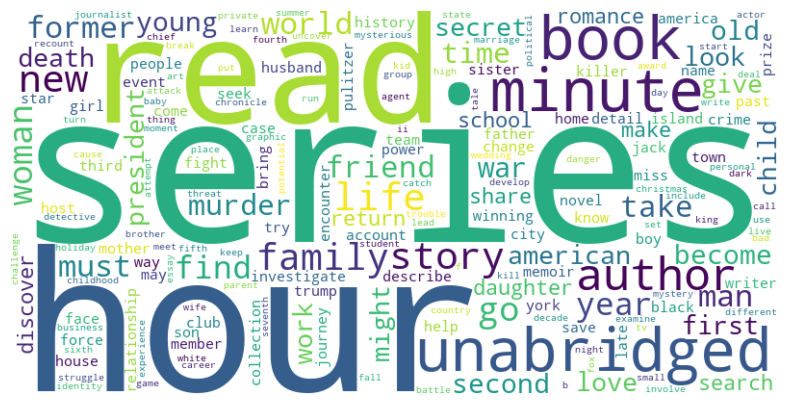

In [296]:
def draw_wordcloud(text, language='en'):
    lemmatized = text.fillna('').apply(lambda x: lemmatizer(x, language=language))
    
    wordcloud = WordCloud(width=800, height=400, background_color='white', collocations=False).generate(' '.join(lemmatized))
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.show()

draw_wordcloud(df_hardcover['description'])

Заметим, что в описании часто встречается слово minute, hour, unabridged. Так показывается длительность чтения одного текста. Также присутствуют и довольно бессмсленные слова для анализа. Например, read, series, author, story, book, new. Добавим их в noise.

In [297]:
noise += ['author', 'minute', 'hour', 'unabridged', 'read', 'series', 'author', 'story', 'book', 'new']

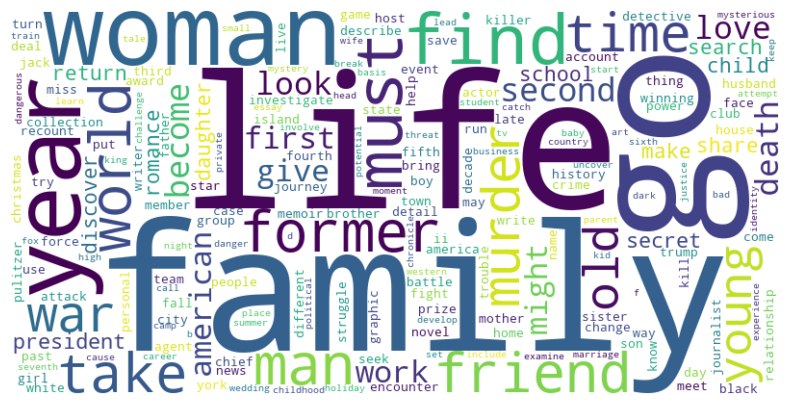

In [298]:
draw_wordcloud(df_hardcover['description'])

In [299]:
df_litres = pd.read_csv('google_x_litres_final.csv')

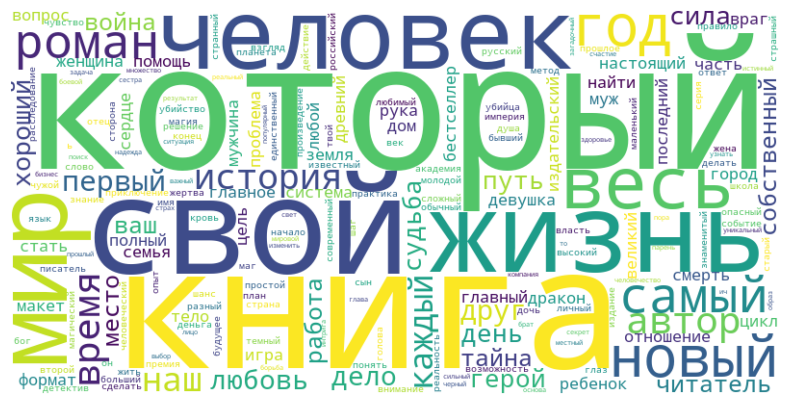

In [300]:
draw_wordcloud(df_litres['description'], language='ru')

Дропнем аналогичные бессмысленные слова в русском

In [301]:
noise += ['а4', 'книга', 'свой', 'который', 'новый', 'история', 'автор', 'роман', 'весь']

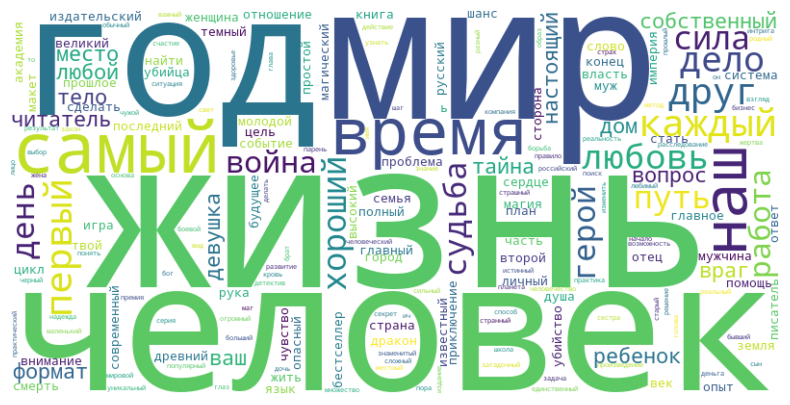

In [302]:
draw_wordcloud(df_litres['description'], language='ru')

In [303]:
pd.Series(noise).to_csv('noise.csv')